# Building an Agentic RAG System with Ollama, LangChain, LangGraph & ChromaDB

## Introduction

In the previous tutorial, we built a **passive RAG** system: a fixed pipeline where every question follows the same path — retrieve 2 documents, stuff them into a prompt, generate an answer. The system has no ability to reason about *whether* it should search, *what* to search for, or *if* the retrieved context is sufficient.

**Agentic RAG** [8] evolves this by giving the LLM **agency** — the ability to make decisions:

| Feature | Passive RAG | Agentic RAG |
| --- | --- | --- |
| Retrieval | Always retrieves (fixed k) | Agent **decides** when to retrieve |
| Query | Raw question → retriever | Agent can **reformulate** the query |
| Iterations | Single pass | Agent can **search multiple times** |
| Self-evaluation | None | Agent **judges** if context is sufficient |
| Routing | Same path for all questions | Agent **routes** based on question type |
| Memory | Stateless | Agent maintains **conversation history** |

### Architecture: From Chain to Agent

**Passive RAG (previous tutorial):**
```
Question → Retriever → Context + Question → LLM → Answer
```

**Agentic RAG (this tutorial):**
```
Question → Agent (LLM) → [Reason] → Should I search? 
                              ├── Yes → Call search tool → Observe results → [Reason again]
                              │            └── Enough info? → No → Reformulate → Search again
                              │            └── Enough info? → Yes → Generate answer
                              └── No → Answer directly (or say "I don't know")
```

This is the **ReAct** (Reasoning + Acting) pattern [9]: the agent reasons about what to do, takes an action (tool call), observes the result, and reasons again.

### Tools Used

- **Ollama** — runs LLMs locally [6]
- **LangChain** — framework for LLM components [5]
- **LangGraph** — framework for building stateful agent graphs [10]
- **ChromaDB** — vector database for embeddings [4]

### References

- [1] Lewis, P. et al. (2020). *Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks*. NeurIPS 2020.
- [3] Mikolov, T. et al. (2013). *Efficient Estimation of Word Representations in Vector Space*. ICLR 2013.
- [4] Chroma. (2023). *ChromaDB: The AI-native open-source embedding database*. https://docs.trychroma.com
- [5] Chase, H. (2022). *LangChain: Building applications with LLMs through composability*. https://langchain.com
- [6] Ollama. (2023). *Run large language models locally*. https://ollama.com
- [7] Gao, Y. et al. (2024). *Retrieval-Augmented Generation for Large Language Models: A Survey*. arXiv:2312.10997.
- [8] Singh, A. et al. (2025). *Agentic RAG: A Survey on Agentic Retrieval-Augmented Generation*. arXiv:2501.09136.
- [9] Yao, S. et al. (2023). *ReAct: Synergizing Reasoning and Acting in Language Models*. ICLR 2023.
- [10] LangGraph. (2024). *LangGraph: Build stateful, multi-actor applications with LLMs*. https://langchain-ai.github.io/langgraph/

## 1. Installation and Setup

We install the same dependencies as the passive RAG tutorial, plus **LangGraph** [10] for building the agent.

In [1]:
# Check that Ollama is installed and running
import subprocess
import sys

try:
    result = subprocess.run(["ollama", "--version"], capture_output=True, text=True, check=True)
    print(f"Ollama is installed: {result.stdout.strip()}")
except (subprocess.CalledProcessError, FileNotFoundError):
    print("Ollama is NOT installed. Install it with:")
    print("   macOS: brew install ollama")
    print("   Linux: curl -fsSL https://ollama.ai/install.sh | sh")
    print("   Then run: ollama serve")

Ollama is installed: ollama version is 0.18.2


In [2]:
# Install all required dependencies (same as passive RAG + LangGraph)
%pip install -q langchain langchain-community langchain-ollama langchain-core langchain-text-splitters
%pip install -q chromadb langchain-chroma
%pip install -q sentence-transformers
%pip install -q langgraph    # NEW: Agent framework [10]

print("All dependencies installed successfully (including LangGraph)")

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
All dependencies installed successfully (including LangGraph)


## 2. Download Required Models

Same models as the passive RAG tutorial [6]:
- **Embedding model** (`nomic-embed-text`): Converts text into vectors [3]
- **Chat model** (`qwen3:4b`): Generates answers and **makes agent decisions**. We use Qwen 3 (4B) instead of `llama3.2` because small Llama models often emit tool calls as JSON text in the message content instead of through the structured `tool_calls` channel, which breaks `create_react_agent`. Qwen 3 has reliable native tool calling at this size.

In [3]:
# Download the required Ollama models
import subprocess

def download_ollama_model(model_name):
    """Download an Ollama model if it is not already available."""
    try:
        result = subprocess.run(["ollama", "list"], capture_output=True, text=True)
        if model_name in result.stdout:
            print(f"Model {model_name} is already available")
            return True

        print(f"Downloading model {model_name}...")
        subprocess.run(["ollama", "pull", model_name], check=True)
        print(f"Model {model_name} downloaded successfully")
        return True

    except subprocess.CalledProcessError as e:
        print(f"Error downloading {model_name}: {e}")
        return False
    except FileNotFoundError:
        print("Ollama is not in PATH. Make sure it is installed and running.")
        return False

embedding_model = "nomic-embed-text"
chat_model = "qwen3:4b"

download_ollama_model(embedding_model)
download_ollama_model(chat_model)

Model nomic-embed-text is already available


pulling manifest ⠋ pulling manifest ⠙ pulling manifest ⠹ pulling manifest ⠸ pulling manifest ⠼ pulling manifest ⠴ pulling manifest ⠦ pulling manifest ⠧ pulling manifest ⠇ pulling manifest ⠏ pulling manifest ⠋ pulling manifest ⠙ pulling manifest ⠹ pulling manifest ⠸ pulling manifest ⠼ pulling manifest ⠴ pulling manifest ⠦ pulling manifest ⠧ pulling manifest ⠇ pulling manifest ⠏ pulling manifest ⠋ pulling manifest ⠙ pulling manifest ⠹ pulling manifest ⠸ pulling manifest ⠼ pulling manifest ⠴ pulling manifest 
pulling 3e4cb1417446:   0% ▕                  ▏ 905 KB/2.5 GB                  pulling manifest 
pulling 3e4cb1417446:   0% ▕                  ▏ 3.9 MB/2.5 GB                  pulling manifest 
pulling 3e4cb1417446:   0% ▕                  ▏ 5.5 MB/2.5 GB                  pulling manifest 
pulling 3e4cb1417446:   0% ▕                  ▏ 8.3 MB/2.5 GB                  pulling manifest 
pulling 3e4cb1417446:   0% ▕                  ▏  11 MB/2.5 GB                  pulling manifest 
pul

Model qwen3:4b downloaded successfully


pulling manifest 
pulling 3e4cb1417446: 100% ▕██████████████████▏ 2.5 GB                         
pulling 2d54db2b9bb2: 100% ▕██████████████████▏ 1.5 KB                         
pulling d18a5cc71b84: 100% ▕██████████████████▏  11 KB                         
pulling cff3f395ef37: 100% ▕██████████████████▏  120 B                         
pulling e18a783aae55: 100% ▕██████████████████▏  487 B                         
verifying sha256 digest ⠦ pulling manifest 
pulling 3e4cb1417446: 100% ▕██████████████████▏ 2.5 GB                         
pulling 2d54db2b9bb2: 100% ▕██████████████████▏ 1.5 KB                         
pulling d18a5cc71b84: 100% ▕██████████████████▏  11 KB                         
pulling cff3f395ef37: 100% ▕██████████████████▏  120 B                         
pulling e18a783aae55: 100% ▕██████████████████▏  487 B                         
verifying sha256 digest ⠧ pulling manifest 
pulling 3e4cb1417446: 100% ▕██████████████████▏ 2.5 GB                         
pulling 2d54db

True

## 3. Import Libraries

In addition to the previous imports, we now import:
- **LangGraph** components for building the agent graph [10]
- **Tool** decorators to wrap functions as agent tools [5]
- **Message types** for the conversation state [5]

In [4]:
# Import all required libraries

# --- Same as passive RAG ---
from langchain_ollama import OllamaEmbeddings, ChatOllama
from langchain_chroma import Chroma
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
import os

# --- NEW: Agentic components ---
from langchain_core.tools import tool                          # Tool decorator [5]
from langchain_core.messages import HumanMessage, SystemMessage # Message types [5]
from langgraph.prebuilt import create_react_agent               # ReAct agent [10]
from langgraph.checkpoint.memory import MemorySaver             # Conversation memory [10]

os.environ["TOKENIZERS_PARALLELISM"] = "false"

print("All libraries imported successfully")
print("  New imports: tool, create_react_agent, MemorySaver")

/opt/miniconda3/envs/IntroLLMs/lib/python3.14/site-packages/langchain_core/_api/deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


All libraries imported successfully
  New imports: tool, create_react_agent, MemorySaver


## 4. Prepare Sample Documents

Same knowledge base as the passive RAG tutorial. We add a few more documents to make the agent's decision-making more interesting.

In [5]:
# Create sample documents — expanded knowledge base
documents_data = [
    {
        "content": "Python is an interpreted, high-level, general-purpose programming language. It was created by Guido van Rossum and first released in 1991. Python emphasizes code readability with its notable use of significant whitespace.",
        "metadata": {"topic": "python_basics", "source": "intro"}
    },
    {
        "content": "Lists in Python are ordered, mutable data structures that can hold elements of different types. They are defined using square brackets [] and elements are separated by commas. Example: my_list = [1, 'hello', 3.14, True]",
        "metadata": {"topic": "python_data_structures", "source": "lists"}
    },
    {
        "content": "Functions in Python are defined using the 'def' keyword followed by the function name and parentheses. Functions can receive parameters and return values using the 'return' keyword. Example: def greet(name): return f'Hello, {name}'",
        "metadata": {"topic": "python_functions", "source": "functions"}
    },
    {
        "content": "Dictionaries in Python are data structures that store key-value pairs. They are mutable and since Python 3.7+ they maintain insertion order. They are defined using curly braces {}. Example: my_dict = {'name': 'Alice', 'age': 30}",
        "metadata": {"topic": "python_data_structures", "source": "dictionaries"}
    },
    {
        "content": "For loops in Python are used to iterate over sequences (lists, tuples, strings, etc.). Syntax: for item in sequence: # code. You can also use range() to iterate a specific number of times: for i in range(10): # code",
        "metadata": {"topic": "python_control_flow", "source": "loops"}
    },
    {
        "content": "Classes in Python are defined using the 'class' keyword. They support inheritance, encapsulation, and polymorphism. The __init__ method is the constructor. Example: class Dog: def __init__(self, name): self.name = name",
        "metadata": {"topic": "python_oop", "source": "classes"}
    },
    {
        "content": "Exception handling in Python uses try/except blocks. You can catch specific exceptions or use a general except clause. The 'finally' block runs regardless of whether an exception occurred. Example: try: x = 1/0 except ZeroDivisionError: print('Cannot divide by zero')",
        "metadata": {"topic": "python_errors", "source": "exceptions"}
    },
    {
        "content": "List comprehensions provide a concise way to create lists. Syntax: [expression for item in iterable if condition]. Example: squares = [x**2 for x in range(10)] creates a list of squares from 0 to 81.",
        "metadata": {"topic": "python_data_structures", "source": "comprehensions"}
    }
]

documents = [
    Document(page_content=d["content"], metadata=d["metadata"])
    for d in documents_data
]

print(f"Created {len(documents)} documents (vs 5 in passive RAG)")
for d in documents:
    print(f"  - [{d.metadata['topic']}] {d.page_content[:60]}...")

Created 8 documents (vs 5 in passive RAG)
  - [python_basics] Python is an interpreted, high-level, general-purpose progra...
  - [python_data_structures] Lists in Python are ordered, mutable data structures that ca...
  - [python_functions] Functions in Python are defined using the 'def' keyword foll...
  - [python_data_structures] Dictionaries in Python are data structures that store key-va...
  - [python_control_flow] For loops in Python are used to iterate over sequences (list...
  - [python_oop] Classes in Python are defined using the 'class' keyword. The...
  - [python_errors] Exception handling in Python uses try/except blocks. You can...
  - [python_data_structures] List comprehensions provide a concise way to create lists. S...


## 5. Configure Embeddings and Vector Store

Same as the passive RAG tutorial — we create the embeddings model [3] and the ChromaDB vector store [4]. The retriever is the same component; what changes is **how** and **when** it gets called.

In [6]:
# Configure embeddings [3]
embeddings = OllamaEmbeddings(model="nomic-embed-text")

# Create vector store [4]
vectorstore = Chroma.from_documents(
    documents=documents,
    embedding=embeddings,
    collection_name="python_docs_agentic",
)

# Create retriever — same component, but now it will be wrapped as a TOOL
retriever = vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 3}  # k=3 since we have more documents
)

print(f"Vector store created with {vectorstore._collection.count()} documents")
print(f"Retriever configured (k=3)")

Vector store created with 8 documents
Retriever configured (k=3)


## 6. Configure the Chat Model

Same model as before, but now we configure it to support **tool calling** — the ability to decide when to invoke external tools [9].

In [7]:
# Configure the Ollama chat model [6]
# We use qwen3:4b instead of llama3.2 because small Llama models tend to emit
# tool calls as plain JSON text in the message content rather than through the
# structured tool_calls channel, which breaks create_react_agent.
llm = ChatOllama(
    model="qwen3:4b",
    temperature=0,
)

# Test the model
try:
    test_response = llm.invoke("Say 'hello' in one word")
    print(f"Chat model working: {test_response.content}")
except Exception as e:

    print(f"Error: {e}")
    print("Make sure Ollama is running: ollama serve")

Chat model working: hello


## 7. Define Agent Tools — The Key Difference

In **passive RAG**, the retriever is hardwired into the pipeline — it always runs. In **Agentic RAG**, the retriever becomes a **tool** that the agent can choose to call (or not) [8].

The `@tool` decorator [5] wraps a Python function so the LLM can:
1. See the tool's **name** and **description**
2. Understand what **arguments** it accepts
3. **Decide** whether to call it based on the user's question
4. Read the **results** and reason about them

This is what makes the RAG system "agentic" — the LLM is no longer a passive text generator, it becomes an **agent** that uses tools to accomplish goals [9].

In [8]:
from pydantic import BaseModel, field_validator
from typing import Any

# Custom schema that coerces 'query' to str BEFORE Pydantic's type validation.
# Some local models (e.g. llama3.2) incorrectly pass query as a dict like
# {'type': '...'} instead of a plain string, which causes a validation error.
class SearchInput(BaseModel):
    query: str

    @field_validator("query", mode="before")
    @classmethod
    def coerce_query_to_str(cls, v: Any) -> str:
        if isinstance(v, dict):
            # Try common keys the model might use, fall back to first value
            return str(
                v.get("query") or v.get("type") or next(iter(v.values()), "")
            ).strip()
        return str(v).strip()


@tool(args_schema=SearchInput)
def search_knowledge_base(query: str) -> str:
    """Search the Python programming knowledge base for relevant information.
    Use this tool when you need to find specific information about Python
    programming concepts, syntax, data structures, or features.
    The query should be a clear description of what you are looking for."""
    docs = retriever.invoke(query)
    if not docs:
        return "No relevant documents found in the knowledge base."

    results = []
    for i, doc in enumerate(docs, 1):
        results.append(
            f"[Document {i} — topic: {doc.metadata.get('topic', 'unknown')}]\n"
            f"{doc.page_content}"
        )
    return "\n\n".join(results)


# List of tools available to the agent
tools = [search_knowledge_base]

print("Agent tools defined:")
for t in tools:
    print(f"  - {t.name}: {t.description[:80]}...")


Agent tools defined:
  - search_knowledge_base: Search the Python programming knowledge base for relevant information.
Use this ...


## 8. Test the Tool Directly

Before building the agent, we verify the tool works correctly when called directly.

In [9]:
# Test the tool manually
result = search_knowledge_base.invoke({"query": "How do I define a class in Python?"})
print("Tool test result:")
print(result)

Tool test result:
[Document 1 — topic: python_oop]
Classes in Python are defined using the 'class' keyword. They support inheritance, encapsulation, and polymorphism. The __init__ method is the constructor. Example: class Dog: def __init__(self, name): self.name = name

[Document 2 — topic: python_basics]
Python is an interpreted, high-level, general-purpose programming language. It was created by Guido van Rossum and first released in 1991. Python emphasizes code readability with its notable use of significant whitespace.

[Document 3 — topic: python_data_structures]
Dictionaries in Python are data structures that store key-value pairs. They are mutable and since Python 3.7+ they maintain insertion order. They are defined using curly braces {}. Example: my_dict = {'name': 'Alice', 'age': 30}


## 9. Build the Agentic RAG System with LangGraph

Now we build the agent using **LangGraph** [10]. The `create_react_agent` function creates a **ReAct agent** [9] — an agent that follows the loop:

1. **Reason**: The LLM thinks about what to do next
2. **Act**: The LLM calls a tool (or decides to respond directly)
3. **Observe**: The LLM reads the tool's output
4. **Repeat**: Back to step 1 until the agent has enough information

### Key differences from the passive RAG chain:

| Passive RAG (LCEL chain) | Agentic RAG (LangGraph) |
| --- | --- |
| `retriever \| format_docs \| prompt \| llm` | `create_react_agent(llm, tools)` |
| Fixed linear pipeline | Dynamic decision graph |
| Always retrieves | Agent decides if/when to retrieve |
| No memory | MemorySaver keeps conversation history |
| One search per question | Agent can search 0, 1, or N times |

In [10]:
# System prompt that defines the agent's behavior
system_prompt = """You are a helpful Python programming assistant with access to a knowledge base.

RULES:
1. When asked about Python concepts, ALWAYS use the search_knowledge_base tool first
   to find relevant information before answering.
2. Base your answers ONLY on the information retrieved from the knowledge base.
3. If the knowledge base does not contain relevant information, clearly state that
   you do not have that information in your knowledge base.
4. If the first search does not return enough information, try searching with
   different or more specific terms.
5. Always cite which topic the information came from.
6. For greetings or simple conversational messages, respond directly without searching.
"""

# Create conversation memory [10]
memory = MemorySaver()

# Build the ReAct agent with LangGraph [10]
agent = create_react_agent(
    model=llm,
    tools=tools,
    prompt=system_prompt,
    checkpointer=memory,  # Enables conversation memory
)

print("Agentic RAG system created!")
print("Components:")
print("  - Agent type: ReAct [9]")
print("  - Framework: LangGraph [10]")
print("  - LLM: qwen3:4b via Ollama [6]")
print("  - Tools: search_knowledge_base (ChromaDB retriever) [4]")
print("  - Memory: MemorySaver (conversation history) [10]")

Agentic RAG system created!
Components:
  - Agent type: ReAct [9]
  - Framework: LangGraph [10]
  - LLM: qwen3:4b via Ollama [6]
  - Tools: search_knowledge_base (ChromaDB retriever) [4]
  - Memory: MemorySaver (conversation history) [10]


/var/folders/q8/mgh1_pbj6p73jpzlql4wy3nh0000gn/T/ipykernel_47816/4140035957.py:20: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent = create_react_agent(


## 10. Helper Function to Run the Agent

We create a helper function that invokes the agent and shows the complete reasoning trace — every step the agent takes, including tool calls and observations.

In [11]:
def ask_agent(question: str, thread_id: str = "default", verbose: bool = True) -> str:
    """Send a question to the agentic RAG system and display the reasoning trace."""

    config = {"configurable": {"thread_id": thread_id}}
    input_message = {"messages": [HumanMessage(content=question)]}

    if verbose:
        print(f"Question: {question}")
        print("=" * 70)

    # Stream agent steps to see the reasoning process
    final_answer = ""
    for step in agent.stream(input_message, config=config, stream_mode="updates"):
        for node_name, node_output in step.items():
            messages = node_output.get("messages", [])
            for msg in messages:
                if verbose:
                    # Show tool calls (agent's decisions)
                    if getattr(msg, "tool_calls", None):
                        for tc in msg.tool_calls:
                            print(f"\n[AGENT DECISION] Call tool: {tc['name']}")
                            print(f"  Query: {tc['args'].get('query', '')}")

                    # Show tool results (observations)
                    elif msg.type == "tool":
                        content_preview = msg.content[:200] + "..." if len(msg.content) > 200 else msg.content
                        print(f"\n[TOOL RESULT] {content_preview}")

                    # Final assistant answer (AIMessage with no tool calls)
                    elif msg.type == "ai":
                        final_answer = msg.content

    if verbose:
        print(f"\n{'=' * 70}")
        print(f"ANSWER: {final_answer}")

    return final_answer

print("Helper function defined. Usage: ask_agent('your question')")


Helper function defined. Usage: ask_agent('your question')


## 11. Test the Agentic RAG System

Let's test the agent with the **same questions** from the passive RAG tutorial. Watch the reasoning trace — the agent **decides** to search, **formulates** a query, **reads** the results, and then **generates** an answer.

In [12]:
# Test 1: Direct knowledge base question (agent should search)
ask_agent("How do you create lists in Python?", thread_id="test1")

Question: How do you create lists in Python?

[AGENT DECISION] Call tool: search_knowledge_base
  Query: how to create lists in Python

[TOOL RESULT] [Document 1 — topic: python_data_structures]
Lists in Python are ordered, mutable data structures that can hold elements of different types. They are defined using square brackets [] and elements are ...

ANSWER: In Python, lists are created using square brackets `[]` with elements separated by commas. For example:

```python
my_list = [1, 'hello', 3.14, True]
```

This is the standard syntax for creating a basic list (as documented in **python_data_structures**). 

Lists can also be generated using list comprehensions (e.g., `[x**2 for x in range(10)]`), but the direct bracket notation is the primary method for creating lists.


"In Python, lists are created using square brackets `[]` with elements separated by commas. For example:\n\n```python\nmy_list = [1, 'hello', 3.14, True]\n```\n\nThis is the standard syntax for creating a basic list (as documented in **python_data_structures**). \n\nLists can also be generated using list comprehensions (e.g., `[x**2 for x in range(10)]`), but the direct bracket notation is the primary method for creating lists."

In [13]:
# Test 2: Question requiring multiple concepts (agent may search multiple times)
ask_agent("What is the difference between lists and dictionaries?", thread_id="test2")

Question: What is the difference between lists and dictionaries?

[AGENT DECISION] Call tool: search_knowledge_base
  Query: difference between lists and dictionaries in Python

[TOOL RESULT] [Document 1 — topic: python_data_structures]
Lists in Python are ordered, mutable data structures that can hold elements of different types. They are defined using square brackets [] and elements are ...

ANSWER: The difference between lists and dictionaries in Python is as follows:

1. **Structure**:
   - **Lists**: Ordered, mutable data structures that store elements of **different types** (e.g., integers, strings, booleans). Defined using square brackets `[]`.
     Example: `my_list = [1, 'hello', 3.14, True]`
   - **Dictionaries**: Key-value pairs where **keys are unique** and values can be of any type. Defined using curly braces `{}`.
     Example: `my_dict = {'name': 'Alice', 'age': 30}`

2. **Order**:
   - Lists maintain **insertion order** (order of elements as added).
   - Dictionaries ma

"The difference between lists and dictionaries in Python is as follows:\n\n1. **Structure**:\n   - **Lists**: Ordered, mutable data structures that store elements of **different types** (e.g., integers, strings, booleans). Defined using square brackets `[]`.\n     Example: `my_list = [1, 'hello', 3.14, True]`\n   - **Dictionaries**: Key-value pairs where **keys are unique** and values can be of any type. Defined using curly braces `{}`.\n     Example: `my_dict = {'name': 'Alice', 'age': 30}`\n\n2. **Order**:\n   - Lists maintain **insertion order** (order of elements as added).\n   - Dictionaries maintain **insertion order** since Python 3.7 (prior to this, order was arbitrary).\n\n3. **Access**:\n   - Lists use **index-based access** (e.g., `my_list[0]`).\n   - Dictionaries use **key-based access** (e.g., `my_dict['name']`).\n\n4. **Use Cases**:\n   - Lists are ideal for sequences where order matters (e.g., ordered collections of items).\n   - Dictionaries are ideal for fast lookups b

In [14]:
# Test 3: Question outside the knowledge base (agent should say it doesn't know)
ask_agent("How do I connect to a PostgreSQL database in Python?", thread_id="test3")

Question: How do I connect to a PostgreSQL database in Python?

[AGENT DECISION] Call tool: search_knowledge_base
  Query: How to connect to PostgreSQL database in Python

[TOOL RESULT] [Document 1 — topic: python_data_structures]
Dictionaries in Python are data structures that store key-value pairs. They are mutable and since Python 3.7+ they maintain insertion order. They are defin...

ANSWER: I don't have information about connecting to PostgreSQL databases in Python in my current knowledge base. The retrieved documents only cover Python data structures (dictionaries, lists) and basic Python characteristics, but not database connectivity topics.

To connect to PostgreSQL in Python, you would typically use the `psycopg2` library (a PostgreSQL adapter for Python), but this information isn't present in my knowledge base.


"I don't have information about connecting to PostgreSQL databases in Python in my current knowledge base. The retrieved documents only cover Python data structures (dictionaries, lists) and basic Python characteristics, but not database connectivity topics.\n\nTo connect to PostgreSQL in Python, you would typically use the `psycopg2` library (a PostgreSQL adapter for Python), but this information isn't present in my knowledge base."

In [15]:
# Test 4: Simple greeting (agent should NOT search — just respond)
ask_agent("Hello! How are you?", thread_id="test4")

Question: Hello! How are you?

ANSWER: Hello! I'm doing great. How can I help you today? 😊


"Hello! I'm doing great. How can I help you today? 😊"

## 12. Demonstrate Conversation Memory

A major advantage of the agentic approach: the agent **remembers** previous messages in the same conversation thread. In passive RAG, every question was independent.

The `MemorySaver` checkpointer [10] stores the full message history per `thread_id`. When the agent receives a new message, it sees the entire conversation context.

In [16]:
# Multi-turn conversation — same thread_id maintains context
THREAD = "conversation_demo"

print("=" * 70)
print("MULTI-TURN CONVERSATION DEMO")
print("=" * 70)

# Turn 1
print("\n--- Turn 1 ---")
ask_agent("What are Python functions?", thread_id=THREAD)

# Turn 2 — references "them" from turn 1
print("\n--- Turn 2 ---")
ask_agent("Can you give me another example of how to use them?", thread_id=THREAD)

# Turn 3 — builds on the conversation
print("\n--- Turn 3 ---")
ask_agent("How would I handle errors inside a function like that?", thread_id=THREAD)

MULTI-TURN CONVERSATION DEMO

--- Turn 1 ---
Question: What are Python functions?

[AGENT DECISION] Call tool: search_knowledge_base
  Query: Python functions

[TOOL RESULT] [Document 1 — topic: python_functions]
Functions in Python are defined using the 'def' keyword followed by the function name and parentheses. Functions can receive parameters and return values using t...

ANSWER: Python functions are defined using the `def` keyword followed by the function name and parentheses. They can accept parameters and return values using the `return` keyword. For example:  
```python
def greet(name):
    return f'Hello, {name}'
```  
This information comes from the **python_functions** topic.

--- Turn 2 ---
Question: Can you give me another example of how to use them?

ANSWER: The knowledge base only contains one example of a Python function:  
```python
def greet(name):
    return f'Hello, {name}'
```  
No additional examples of Python functions are present in the current knowledge base.



'To handle errors inside a Python function, you can use `try/except` blocks within the function definition. Here\'s an example based on the knowledge base:\n\n```python\ndef safe_division(a, b):\n    try:\n        result = a / b\n    except ZeroDivisionError:\n        return "Cannot divide by zero"\n    except TypeError:\n        return "Both arguments must be numbers"\n    else:\n        return result\n```\n\nThis example catches specific exceptions (like `ZeroDivisionError` and `TypeError`) and provides meaningful feedback. The `else` clause runs if no exceptions occur, and the `finally` block (not shown here) would execute regardless of exceptions. This information comes from the **python_errors** topic.'

## 13. Compare: Passive RAG vs Agentic RAG

Let's rebuild the passive RAG chain from the previous tutorial and compare both approaches side by side on the same question.

In [17]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser

# Rebuild the passive RAG chain (from previous tutorial)
rag_template = """Answer the question based ONLY on the following context.
If the information is not in the context, say you do not have enough information.

Context:
{context}

Question: {question}

Answer:"""

rag_prompt = ChatPromptTemplate.from_template(rag_template)

def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

passive_rag_chain = (
    {"context": retriever | format_docs, "question": RunnablePassthrough()}
    | rag_prompt
    | llm
    | StrOutputParser()
)

print("Passive RAG chain rebuilt for comparison")

Passive RAG chain rebuilt for comparison


In [18]:
# Side-by-side comparison
comparison_questions = [
    "How do I handle errors in Python?",           # Both should answer well
    "What is the capital of France?",               # Outside knowledge base
    "Hello!",                                       # Not a knowledge question
]

for question in comparison_questions:
    print("#" * 70)
    print(f"QUESTION: {question}")
    print("#" * 70)

    # Passive RAG — always searches, always answers
    print("\n[PASSIVE RAG]")
    passive_answer = passive_rag_chain.invoke(question)
    print(f"  {passive_answer[:300]}")

    # Agentic RAG — decides whether to search
    print("\n[AGENTIC RAG]")
    ask_agent(question, thread_id=f"compare_{hash(question)}")

    print()

######################################################################
QUESTION: How do I handle errors in Python?
######################################################################

[PASSIVE RAG]
  Answer: In Python, errors are handled using try/except blocks. You can catch specific exceptions or use a general except clause. The 'finally' block runs regardless of whether an exception occurred.

[AGENTIC RAG]
Question: How do I handle errors in Python?

[AGENT DECISION] Call tool: search_knowledge_base
  Query: how to handle errors in Python

[TOOL RESULT] [Document 1 — topic: python_errors]
Exception handling in Python uses try/except blocks. You can catch specific exceptions or use a general except clause. The 'finally' block runs regardless of whethe...

ANSWER: The information about handling errors in Python comes from the **python_errors** topic. Here's how to handle errors in Python:

1. **Use `try/except` blocks** to catch exceptions.
2. **Catch specific exceptions** (e.g., 

## 14. Visualize the Agent Graph

LangGraph [10] lets us visualize the agent's decision graph. This shows the **nodes** (processing steps) and **edges** (transitions) that the agent follows.

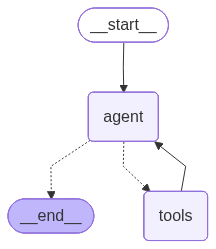

In [19]:
# Display the agent's decision graph
try:
    from IPython.display import Image, display
    graph_image = agent.get_graph().draw_mermaid_png()
    display(Image(graph_image))
except Exception as e:
    # Fallback: show the text representation
    print("Graph visualization (install pygraphviz for image):")
    print()
    print(agent.get_graph().draw_mermaid())

## 15. Advanced: Adding More Tools

The power of the agentic approach is that you can add **more tools** beyond just retrieval. The agent decides which tool to use based on the question. This is a key advantage over passive RAG [8].

In [20]:
# Define additional tools

@tool
def search_by_topic(topic: str) -> str:
    """Search the knowledge base filtering by a specific topic.
    Available topics: python_basics, python_data_structures, python_functions,
    python_control_flow, python_oop, python_errors.
    Use this when you know exactly which topic area to look in."""
    # Use metadata filtering in ChromaDB
    results = vectorstore.similarity_search(
        query=topic,
        k=3,
        filter={"topic": topic}
    )
    if not results:
        return f"No documents found for topic '{topic}'. Available topics: python_basics, python_data_structures, python_functions, python_control_flow, python_oop, python_errors."

    formatted = []
    for i, doc in enumerate(results, 1):
        formatted.append(f"[{i}] {doc.page_content}")
    return "\n\n".join(formatted)


@tool
def list_available_topics() -> str:
    """List all topics available in the knowledge base.
    Use this when the user asks what topics or subjects are covered,
    or when you need to know what information is available."""
    all_docs = vectorstore.get()
    topics = set()
    if all_docs and "metadatas" in all_docs:
        for meta in all_docs["metadatas"]:
            if meta and "topic" in meta:
                topics.add(meta["topic"])

    if not topics:
        return "No topics found in the knowledge base."

    topic_list = sorted(topics)
    return f"Available topics in the knowledge base ({len(topic_list)}): " + ", ".join(topic_list)


# Create enhanced agent with multiple tools
enhanced_tools = [search_knowledge_base, search_by_topic, list_available_topics]

print("Enhanced tools defined:")
for t in enhanced_tools:
    print(f"  - {t.name}: {t.description[:70]}...")

Enhanced tools defined:
  - search_knowledge_base: Search the Python programming knowledge base for relevant information....
  - search_by_topic: Search the knowledge base filtering by a specific topic.
Available top...
  - list_available_topics: List all topics available in the knowledge base.
Use this when the use...


In [21]:
# Build the enhanced agent with multiple tools
enhanced_system_prompt = """You are a helpful Python programming assistant with access to a knowledge base.

You have the following tools:
1. search_knowledge_base: General semantic search. Use for most questions.
2. search_by_topic: Search filtered by topic. Use when you know the exact topic.
3. list_available_topics: See what topics exist. Use when asked about coverage.

RULES:
1. For Python questions, ALWAYS search the knowledge base before answering.
2. Base answers ONLY on retrieved information.
3. If insufficient info, try a different search query or tool.
4. If still not found, say you don't have that information.
5. For greetings or meta-questions, respond directly.
"""

enhanced_memory = MemorySaver()

enhanced_agent = create_react_agent(
    model=llm,
    tools=enhanced_tools,
    prompt=enhanced_system_prompt,
    checkpointer=enhanced_memory,
)

print("Enhanced agent created with 3 tools!")

Enhanced agent created with 3 tools!


/var/folders/q8/mgh1_pbj6p73jpzlql4wy3nh0000gn/T/ipykernel_47816/3665426314.py:19: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  enhanced_agent = create_react_agent(


In [22]:
def ask_enhanced_agent(question: str, thread_id: str = "enhanced", verbose: bool = True) -> str:
    """Send a question to the enhanced agentic RAG system."""
    config = {"configurable": {"thread_id": thread_id}}
    input_message = {"messages": [HumanMessage(content=question)]}

    if verbose:
        print(f"Question: {question}")
        print("=" * 70)

    final_answer = ""
    for step in enhanced_agent.stream(input_message, config=config, stream_mode="updates"):
        for node_name, node_output in step.items():
            messages = node_output.get("messages", [])
            for msg in messages:
                if verbose:
                    if hasattr(msg, "tool_calls") and msg.tool_calls:
                        for tc in msg.tool_calls:
                            print(f"\n[AGENT] Call: {tc['name']}({tc['args']})")
                    elif msg.type == "tool":
                        preview = msg.content[:150] + "..." if len(msg.content) > 150 else msg.content
                        print(f"[RESULT] {preview}")
                    elif msg.type == "ai" and not getattr(msg, "tool_calls", None):
                        final_answer = msg.content

    if verbose:
        print(f"\n{'=' * 70}")
        print(f"ANSWER: {final_answer}")

    return final_answer

print("Enhanced helper function defined.")

Enhanced helper function defined.


In [23]:
# Test the enhanced agent — it can choose between multiple tools

print("--- Test: What topics are available? ---")
ask_enhanced_agent("What topics do you have information about?", thread_id="enhanced1")

print("\n\n--- Test: Topic-specific search ---")
ask_enhanced_agent("Tell me everything about error handling in Python", thread_id="enhanced2")

print("\n\n--- Test: General search ---")
ask_enhanced_agent("How do list comprehensions work?", thread_id="enhanced3")

--- Test: What topics are available? ---
Question: What topics do you have information about?

[AGENT] Call: list_available_topics({})
[RESULT] Available topics in the knowledge base (6): python_basics, python_control_flow, python_data_structures, python_errors, python_functions, python_oop

ANSWER: I have information about the following topics:  
- `python_basics`  
- `python_control_flow`  
- `python_data_structures`  
- `python_errors`  
- `python_functions`  
- `python_oop`


--- Test: Topic-specific search ---
Question: Tell me everything about error handling in Python

[AGENT] Call: search_by_topic({'topic': 'python_errors'})
[RESULT] [1] Exception handling in Python uses try/except blocks. You can catch specific exceptions or use a general except clause. The 'finally' block runs re...

ANSWER: Exception handling in Python is primarily achieved using `try/except` blocks. Here's what you need to know based on the knowledge base:

1. **Try/Except Blocks**: The core mechanism for ha

"List comprehensions in Python provide a concise way to create lists using a single line of code. The basic syntax is:\n\n```python\n[expression for item in iterable if condition]\n```\n\n**Example**:  \n`squares = [x**2 for x in range(10)]` creates a list of squares from 0 to 81 (`[0, 1, 4, 9, 16, 25, 36, 49, 64, 81]`).\n\nThey are particularly useful for:\n1. Iterating over sequences (e.g., lists, ranges)\n2. Applying transformations or filters to elements\n3. Replacing nested loops with cleaner code\n\nThis feature is part of Python's data structures and control flow capabilities, as noted in the knowledge base."

## 16. Interactive Usage

Change the question and run the cell. The agent will reason about the best approach.

In [24]:
# Ask your own question — change and run
question = "How can I use Python to create spaceships?"

ask_enhanced_agent(question, thread_id="interactive")

Question: How can I use Python to create spaceships?

[AGENT] Call: search_knowledge_base({'query': 'how to create spaceships in Python'})
[RESULT] [Document 1 — topic: python_basics]
Python is an interpreted, high-level, general-purpose programming language. It was created by Guido van Rossum and...

ANSWER: The knowledge base does not contain information about creating spaceships in Python. This topic is not covered in the available Python programming resources (which focus on basics, data structures, functions, control flow, OOP, and errors). 

Spaceships are typically created in game development contexts (e.g., using libraries like Pygame), but this specific use case isn't documented in the provided knowledge base. If you're looking for game development examples, you might need to consult external resources beyond this knowledge base.


"The knowledge base does not contain information about creating spaceships in Python. This topic is not covered in the available Python programming resources (which focus on basics, data structures, functions, control flow, OOP, and errors). \n\nSpaceships are typically created in game development contexts (e.g., using libraries like Pygame), but this specific use case isn't documented in the provided knowledge base. If you're looking for game development examples, you might need to consult external resources beyond this knowledge base."

## 17. Optional Cleanup

In [25]:
# Optional cleanup — uncomment to delete the vector store
# vectorstore.delete_collection()
# print("Vector store deleted")

print("Tutorial complete. Vector store and agent remain in memory.")

Tutorial complete. Vector store and agent remain in memory.


## Conclusions and Next Steps

You have evolved from a **passive RAG** system to an **Agentic RAG** system.

### What Changed

| Concept | Passive RAG (previous tutorial) | Agentic RAG (this tutorial) |
| --- | --- | --- |
| **Framework** | LCEL chain [5] | LangGraph agent [10] |
| **Retriever role** | Hardwired pipeline step | Tool the agent can call |
| **Decision making** | None — fixed path | LLM decides when/what to search [9] |
| **Memory** | Stateless | MemorySaver keeps conversation [10] |
| **Multi-step** | Always 1 retrieval | Agent can search 0-N times [8] |
| **Extensibility** | Add more chain steps | Add more tools |

### What We Learned

1. **Tools** [5] — How to wrap functions as tools the LLM can use
2. **ReAct pattern** [9] — How agents reason and act in a loop
3. **LangGraph** [10] — How to build stateful agent applications
4. **Conversation memory** [10] — How to maintain context across turns
5. **Agentic RAG** [8] — How giving the LLM agency improves RAG systems

### Architecture Summary

```
Question → Agent (LLM) → [Reason] → Tool call? 
                              ├── search_knowledge_base(query) → Results → [Reason]
                              ├── search_by_topic(topic) → Results → [Reason]
                              ├── list_available_topics() → Results → [Reason]
                              └── [Enough info] → Generate Answer
```

### Possible Improvements

- **More tools**: Add web search, calculator, code execution tools
- **Multi-agent**: Multiple specialized agents collaborating [8]
- **Planning**: Agent plans a sequence of steps before executing [8]
- **Evaluation**: Agent self-evaluates answer quality before responding
- **Streaming**: Stream the agent's reasoning in real-time to a UI
- **Human-in-the-loop**: Agent asks the user for clarification when needed

### References

- [1] Lewis, P. et al. (2020). *Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks*. NeurIPS 2020. arXiv:2005.11401
- [3] Mikolov, T. et al. (2013). *Efficient Estimation of Word Representations in Vector Space*. ICLR 2013. arXiv:1301.3781
- [4] Chroma. (2023). *ChromaDB: The AI-native open-source embedding database*. https://docs.trychroma.com
- [5] Chase, H. (2022). *LangChain: Building applications with LLMs through composability*. https://langchain.com
- [6] Ollama. (2023). *Run large language models locally*. https://ollama.com
- [7] Gao, Y. et al. (2024). *Retrieval-Augmented Generation for Large Language Models: A Survey*. arXiv:2312.10997
- [8] Singh, A. et al. (2025). *Agentic RAG: A Survey on Agentic Retrieval-Augmented Generation*. arXiv:2501.09136
- [9] Yao, S. et al. (2023). *ReAct: Synergizing Reasoning and Acting in Language Models*. ICLR 2023. arXiv:2210.03629
- [10] LangGraph. (2024). *LangGraph: Build stateful, multi-actor applications with LLMs*. https://langchain-ai.github.io/langgraph/